## Notebook Objective

This notebook performs Large Language Model (LLM)-assisted annotation to automatically generate aspect-level sentiment labels for Indonesian perfume reviews.

The annotation process uses Google Gemini to identify predefined perfume-related aspects and assign the corresponding sentiment for each review. To improve reliability, the pipeline incorporates batch processing, checkpointing, and automatic retry mechanisms, allowing the annotation process to resume safely if interrupted.

The final output of this notebook is an aspect-level annotated dataset that will be used for manual validation and transformer fine-tuning in the next process.

# Preparation - Load Clean Review Dataset

Load the cleaned review dataset prepared during Sprint 2. This dataset has already been filtered by removing missing reviews, irrelevant comments, and excessive whitespaces while assigning a unique identifier for each review.

In [2]:
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATA_PATH = "/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/data/interim/perfume_review_clean.csv"

In [5]:
pd.set_option(
    "display.max_colwidth",
    None
)

In [6]:
df = pd.read_csv(DATA_PATH)

df.head()

,review_id,brand,product,username,rating,tanggal,review,review_length
0,RVW_00001,HMNS,Philea,J***a,5,3 bulan lalu,"Wanginya pas buat saya..elegant, ringan, seger..box kemasannya keren, botolnya juga simple elwgant, keren..gak nyangka aja ownernya alumni ITB..😄",145
1,RVW_00002,HMNS,Philea,Z***f,5,10 bulan lalu,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,247
2,RVW_00003,HMNS,Philea,F***m,5,7 bulan lalu,"produk sesuai deskripsi, produk berkualitas, harga bersaing, pengemasan baik, pengiriman baik",93
3,RVW_00004,HMNS,Philea,Q***z,5,3 minggu lalu,"pengiriman aman dan cepat, belanja dapet harga oke dan pastinya di jamin ori berawal dari nyobain bodymist nya dan suka banget aroma segarnya yang ringan dan nyari tau untuk produk parfum dan langsung pesan ternyata aroma nya beda tipis tipis aja untuk ketahanan belom cobain",275
4,RVW_00005,HMNS,Philea,shabrina,5,10 bulan lalu,"packing aman banget, wangi ny bener2 se enakk itu, apa lagi pas udh dry done nya🥹🥹🥹, the besttt pwwollllll",106


# Sprint 4 - Setup LLM Annotation Pipeline

**Objective**

Establish a reliable and consistent annotation workflow to generate aspect-level sentiment labels that can serve as high-quality training data for ABSA model development.

## Configure Gemini API

In [1]:
!pip install -q google-genai pandas tqdm

In [7]:
from google.colab import userdata
from google import genai

API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=API_KEY)

print("Connection established successfully. Ready to proceed.")

Connection established successfully. Ready to proceed.


## Define Annotation Guidelines

Insights from the exploratory text analysis in Sprint 3 were incorporated into the annotation prompt to define perfume-specific aspects and provide clear labeling instructions. This reduces ambiguity during annotation and helps the LLM generate more consistent and contextually relevant aspect labels.

In [ ]:
import json
import time


PROMPT_TEMPLATE = """
You are an expert Aspect-Based Sentiment Analysis (ABSA) annotator specializing in Indonesian e-commerce perfume reviews.

The input reviews are written in Indonesian and may contain:
- informal language,
- abbreviations,
- typos,
- slang,
- mixed expressions.

Your task is to analyze each review and extract:
1. The perfume aspects being discussed.
2. The sentiment expressed toward each aspect.

You may ONLY classify reviews into these aspects:

1. Aroma
Definition:
Customer opinion about fragrance smell, scent profile, notes, freshness, sweetness, or overall scent characteristics.

2. Longevity
Definition:
Customer opinion about how long the perfume lasts after application, including durability and staying power.

3. Projection
Definition:
Customer opinion about scent projection, intensity, sillage, how far the fragrance can be detected, or whether the scent is strong/weak.

4. Packaging
Definition:
Customer opinion about bottle design, box, packaging quality, and product presentation.

5. Value for Money
Definition:
Customer opinion about whether the perfume quality is worth the price paid.

Annotation Rules:
- A single review may contain multiple aspects.
- Only assign an aspect when it is explicitly mentioned or strongly implied.
- Do not infer aspects that are not discussed.
- Assign sentiment based on the customer's opinion toward that specific aspect.
- Ignore seller service, shipping, delivery, and transaction experience.
- Assign Value for Money only when price, affordability, worthiness, or price-quality comparison is discussed.
- If no perfume-related aspect is mentioned, return an empty aspects list.

Sentiment labels:
- positive
- negative
- neutral

Output Format:
You MUST reply ONLY with a valid JSON array.
Do not include explanations, markdown, or additional text.

Example:

[
  {{
    "review_id": "RVW001",
    "aspects": [
      {{
        "aspect": "Aroma",
        "sentiment": "positive"
      }},
      {{
        "aspect": "Longevity",
        "sentiment": "negative"
      }}
    ]
  }}
]


Reviews to analyze:

{reviews_block}
"""

## Build Annotation Functions

In [ ]:
def build_batch_prompt(batch_df, text_col):

    lines = []

    for _, row in batch_df.iterrows():

        text = str(row[text_col]).replace("\n", " ")

        lines.append(
            f"""
Review ID: {row['review_id']}
Review Text: {text}
"""
        )

    reviews_block = "\n".join(lines)

    return PROMPT_TEMPLATE.format(
        reviews_block=reviews_block
    )

In [ ]:
def call_gemini(prompt, retries=3):

    for attempt in range(retries):

        try:

            resp = client.models.generate_content(
                model="gemini-3.1-flash-lite",
                contents=prompt,
            )

            text = resp.text.strip()


            text = (
                text
                .replace("```json", "")
                .replace("```", "")
                .strip()
            )


            start = text.find("[")
            end = text.rfind("]") + 1

            text = text[start:end]

            return json.loads(text)


        except Exception as e:

            print(
                f"Retry {attempt+1}/{retries}: {e}"
            )

            time.sleep(
                5 * (attempt + 1)
            )


    return None

These functions establish an automated annotation pipeline by constructing standardized prompts, submitting review batches to the Gemini model, and returning structured annotation results.

## Validate Annotation Pipeline

In [ ]:
# test with sample dataset
test_df = df.head(10)

test_prompt = build_batch_prompt(
    test_df,
    "review"
)

test_result = call_gemini(
    test_prompt
)

test_result

[{'review_id': 'RVW_00001',
  'aspects': [{'aspect': 'Aroma', 'sentiment': 'positive'},
   {'aspect': 'Packaging', 'sentiment': 'positive'}]},
 {'review_id': 'RVW_00002',
  'aspects': [{'aspect': 'Aroma', 'sentiment': 'positive'},
   {'aspect': 'Longevity', 'sentiment': 'positive'},
   {'aspect': 'Packaging', 'sentiment': 'positive'}]},
 {'review_id': 'RVW_00003',
  'aspects': [{'aspect': 'Value for Money', 'sentiment': 'positive'},
   {'aspect': 'Packaging', 'sentiment': 'positive'}]},
 {'review_id': 'RVW_00004',
  'aspects': [{'aspect': 'Value for Money', 'sentiment': 'positive'},
   {'aspect': 'Aroma', 'sentiment': 'positive'}]},
 {'review_id': 'RVW_00005',
  'aspects': [{'aspect': 'Packaging', 'sentiment': 'positive'},
   {'aspect': 'Aroma', 'sentiment': 'positive'}]},
 {'review_id': 'RVW_00006',
  'aspects': [{'aspect': 'Aroma', 'sentiment': 'positive'}]},
 {'review_id': 'RVW_00007',
  'aspects': [{'aspect': 'Aroma', 'sentiment': 'positive'}]},
 {'review_id': 'RVW_00008',
  'aspec

**Observation**

The pilot annotation successfully generated valid JSON outputs with correctly identified aspect-sentiment pairs, indicating that the pipeline is ready for large-scale annotation.

# Sprint 5 - Perform Large-scale Annotation

**Objective**

Generate high-quality aspect-level sentiment labels for the complete review dataset while ensuring robustness through checkpointing and automatic retry mechanisms.

In [ ]:
import os
from tqdm import tqdm


TEXT_COL = "review"

BATCH_SIZE = 15

SLEEP_BETWEEN_CALLS = 4.5

CHECKPOINT_FILE = (
    "/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/"
    "data/interim/checkpoint_results.json"
)

FAILED_FILE = (
    "/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/"
    "data/interim/failed_batches.json"
)


# Load checkpoint

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, "r") as f:
        all_results = json.load(f)

    done_ids = set(
        r["review_id"]
        for r in all_results
    )

    print(
        f"Resume: {len(all_results)} reviews completed"
    )

else:
    all_results = []
    done_ids = set()

failed_batches = []

for start in tqdm(
    range(0, len(df), BATCH_SIZE)
):
    batch = df.iloc[
        start:start+BATCH_SIZE
    ]

    # skip if done

    if set(batch["review_id"]).issubset(done_ids):
        continue

    prompt = build_batch_prompt(
        batch,
        TEXT_COL
    )

    result = call_gemini(prompt)

    if result is None:
        failed_batches.append(start)
        continue

    for item in result:
        review_id = item["review_id"]

        if review_id in done_ids:
            continue

        review_text = (
            batch.loc[
                batch["review_id"] == review_id,
                TEXT_COL
            ]
            .iloc[0]
        )

        all_results.append(
            {
                "review_id": review_id,
                "review_text": review_text,
                "aspects": item["aspects"]
            }
        )

        done_ids.add(review_id)

    # checkpoint

    with open(
        CHECKPOINT_FILE,
        "w"
    ) as f:
        json.dump(
            all_results,
            f,
            ensure_ascii=False,
            indent=2
        )

    time.sleep(
        SLEEP_BETWEEN_CALLS
    )

with open(
    FAILED_FILE,
    "w"
) as f:

    json.dump(
        failed_batches,
        f
    )

print(
    f"""
Finished.
Success: {len(all_results)} reviews
Failed batches: {len(failed_batches)}
"""
)

## Save Annotation Results

In [ ]:
annotation_df = pd.DataFrame(all_results)

annotation_df.head()

In [ ]:
annotation_df.to_csv(
    "/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/data/processed/perfume_review_annotation.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Annotation dataset saved!")

The annotation results are successfully stored in structured JSON and tabular formats, preserving both review identifiers and extracted aspect-level sentiments.

## Flatten Annotation

Transform the nested LLM annotation output into a tabular format by creating one row for each aspect–sentiment pair. This structure simplifies exploratory analysis and serves as the input format for downstream model training.

In [78]:
annotation_df = pd.read_csv(
    "/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/data/processed/perfume_review_annotation.csv",
    encoding="utf-8-sig"
)

print(f"Total annotated reviews: {len(annotation_df):,}")
annotation_df.head()

Total annotated reviews: 5,578


,review_id,review_text,aspects
0,RVW_00001,"Wanginya pas buat saya..elegant, ringan, seger..box kemasannya keren, botolnya juga simple elwgant, keren..gak nyangka aja ownernya alumni ITB..😄","[{'aspect': 'Aroma', 'sentiment': 'positive'}, {'aspect': 'Packaging', 'sentiment': 'positive'}]"
1,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,"[{'aspect': 'Aroma', 'sentiment': 'positive'}, {'aspect': 'Longevity', 'sentiment': 'positive'}, {'aspect': 'Packaging', 'sentiment': 'positive'}]"
2,RVW_00003,"produk sesuai deskripsi, produk berkualitas, harga bersaing, pengemasan baik, pengiriman baik","[{'aspect': 'Value for Money', 'sentiment': 'positive'}, {'aspect': 'Packaging', 'sentiment': 'positive'}]"
3,RVW_00004,"pengiriman aman dan cepat, belanja dapet harga oke dan pastinya di jamin ori berawal dari nyobain bodymist nya dan suka banget aroma segarnya yang ringan dan nyari tau untuk produk parfum dan langsung pesan ternyata aroma nya beda tipis tipis aja untuk ketahanan belom cobain","[{'aspect': 'Value for Money', 'sentiment': 'positive'}, {'aspect': 'Aroma', 'sentiment': 'positive'}]"
4,RVW_00005,"packing aman banget, wangi ny bener2 se enakk itu, apa lagi pas udh dry done nya🥹🥹🥹, the besttt pwwollllll","[{'aspect': 'Packaging', 'sentiment': 'positive'}, {'aspect': 'Aroma', 'sentiment': 'positive'}]"


In [79]:
import pandas as pd
import ast

def parse_aspects(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        parsed = ast.literal_eval(x)
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

annotation_df["aspects_parsed"] = annotation_df["aspects"].apply(parse_aspects)

In [80]:
def add_none_placeholder(aspect_list):
    if len(aspect_list) == 0:
        return [{"aspect": "No Aspect", "sentiment": "None"}]
    return aspect_list

annotation_df["aspects_final"] = annotation_df["aspects_parsed"].apply(add_none_placeholder)

In [81]:
flat_df = annotation_df.explode("aspects_final").reset_index(drop=True)

aspect_expanded = pd.json_normalize(flat_df["aspects_final"])

flat_df = pd.concat(
    [flat_df.drop(columns=["aspects", "aspects_parsed", "aspects_final"]), aspect_expanded],
    axis=1
)

print(f"Total rows after flatten: {len(flat_df):,}")
flat_df.head(5)

Total rows after flatten: 8,086


,review_id,review_text,aspect,sentiment
0,RVW_00001,"Wanginya pas buat saya..elegant, ringan, seger..box kemasannya keren, botolnya juga simple elwgant, keren..gak nyangka aja ownernya alumni ITB..😄",Aroma,positive
1,RVW_00001,"Wanginya pas buat saya..elegant, ringan, seger..box kemasannya keren, botolnya juga simple elwgant, keren..gak nyangka aja ownernya alumni ITB..😄",Packaging,positive
2,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,Aroma,positive
3,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,Longevity,positive
4,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,Packaging,positive


In [84]:
print(flat_df["aspect"].value_counts(dropna=False))
print(flat_df["sentiment"].value_counts(dropna=False))

aspect
Aroma              4145
Packaging          1287
Longevity          1002
No Aspect           880
Value for Money     432
Projection          340
Name: count, dtype: int64
sentiment
positive    6604
None         880
negative     355
neutral      247
Name: count, dtype: int64


In [85]:
none_count = (flat_df["aspect"] == "No Aspect").sum()
total_review = annotation_df["review_id"].nunique()
print(f"Reviews without aspect (No Aspect): {none_count:,} out of {total_review:,} unique reviews")

flat_df[flat_df["aspect"] == "No Aspect"].head()

Reviews without aspect (No Aspect): 880 out of 5,578 unique reviews


,review_id,review_text,aspect,sentiment
13,RVW_00008,"Kualitas produk: Bagus bangeettttt 💯 Udah cobain yg Elea skrg cobain yg Philea nya, double combo happy nyaaaa 💃🏻💃🏻💃🏻💕💕💕💕 Terimakasih all tim dan ka tsana , aku sukak produknya🙏🏻🤗",No Aspect,None
19,RVW_00012,Kualitas produk: SANGAT REKOMENDASI!!! GA MENYESAL SAMA SEKALI SAYANG PAUS DAN HMNS<3,No Aspect,None
34,RVW_00024,"finally arrived home, my philea💚",No Aspect,None
36,RVW_00026,"Kualitas produk: Baguss banget, sukaaa bangett",No Aspect,None
65,RVW_00045,"Seperti biasa ga pernah kecewa. Setelah 4 botol elea,akhirnya botol pertama philea sampai",No Aspect,None


In [83]:
output_path = "/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/data/processed/perfume_review_flattened.csv"

flat_df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Saved: {output_path}")
print(f"Total Rows: {len(flat_df):,}")

Saved: /content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/data/processed/perfume_review_flattened.csv
Total Rows: 8,086


# Sprint 6 - Explore Annotation Results

**Objective**

Understand the structure and quality of the annotated dataset by analyzing annotation patterns and verifying LLM-generated labels against the original reviews to ensure their suitability for ABSA model development.


## Load Flat Annotation Data

In [151]:
df = pd.read_csv(output_path)

df.head()

,review_id,review_text,aspect,sentiment
0,RVW_00001,"Wanginya pas buat saya..elegant, ringan, seger..box kemasannya keren, botolnya juga simple elwgant, keren..gak nyangka aja ownernya alumni ITB..😄",Aroma,positive
1,RVW_00001,"Wanginya pas buat saya..elegant, ringan, seger..box kemasannya keren, botolnya juga simple elwgant, keren..gak nyangka aja ownernya alumni ITB..😄",Packaging,positive
2,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,Aroma,positive
3,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,Longevity,positive
4,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,Packaging,positive


## Aspect Distribution

In [152]:
df_full = flat_df.copy()
df_aspect = flat_df[flat_df["aspect"] != "No Aspect"].copy()

print(f"Full rows (incl. no-aspect): {len(df_full):,}")
print(f"Aspect-only rows: {len(df_aspect):,}")
print(f"No-aspect rows: {len(df_full) - len(df_aspect):,} ({(len(df_full)-len(df_aspect))/len(df_full)*100:.1f}%)")

Full rows (incl. no-aspect): 8,086
Aspect-only rows: 7,206
No-aspect rows: 880 (10.9%)


In [153]:
import matplotlib.pyplot as plt

In [154]:
aspect_dist = df_aspect["aspect"].value_counts()
print("Aspect distribution:")
print(aspect_dist)

Aspect distribution:
aspect
Aroma              4145
Packaging          1287
Longevity          1002
Value for Money     432
Projection          340
Name: count, dtype: int64


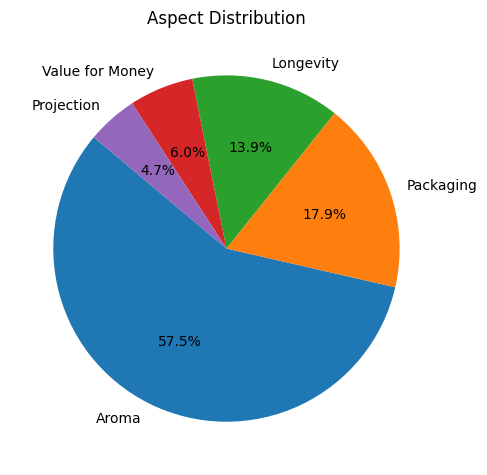

In [155]:
aspect_counts = df_aspect["aspect"].value_counts()

aspect_counts.plot(
    kind="pie",
    figsize=(5, 5),
    title="Aspect Distribution",
    autopct='%1.1f%%',
    startangle=140
)
plt.ylabel("")
plt.tight_layout()
plt.show()

## Sentiment Distribution

In [156]:
sentiment_count = df_aspect["sentiment"].value_counts()

sentiment_percentage = (
    df_aspect["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
)

print("Overall Sentiment Distribution:")

for sentiment, count in sentiment_count.items():
    percentage = sentiment_percentage[sentiment]
    print(f"{sentiment}: {count:,} ({percentage:.2f}%)")

Overall Sentiment Distribution:
positive: 6,604 (91.65%)
negative: 355 (4.93%)
neutral: 247 (3.43%)


In [157]:
aspect_sentiment = (
    df_aspect.groupby(["aspect", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

aspect_sentiment["Total"] = aspect_sentiment.sum(axis=1)

total_row = aspect_sentiment.sum(numeric_only=True).to_frame().T
total_row.index = ["Total"]

aspect_sentiment_full = pd.concat([aspect_sentiment, total_row])

print(aspect_sentiment_full)

sentiment        negative  neutral  positive  Total
Aroma                  73       99      3973   4145
Longevity              76       97       829   1002
Packaging             149       20      1118   1287
Projection             39       23       278    340
Value for Money        18        8       406    432
Total                 355      247      6604   7206


## Review Per Aspect

In [158]:
# Count aspects per review_id (0 for reviews with "No Aspect")
aspect_count_per_review = df_full.groupby("review_id")["aspect"].apply(
    lambda x: 0 if (x == "No Aspect").any() else len(x)
).reset_index(name="n_aspects")

summary = aspect_count_per_review["n_aspects"].value_counts().sort_index().reset_index()
summary.columns = ["n_aspects", "review_count"]
summary["percentage"] = (summary["review_count"] / summary["review_count"].sum() * 100).round(2)
summary = summary.sort_values("n_aspects").reset_index(drop=True)

print(summary)

   n_aspects  review_count  percentage
0          0           880       15.78
1          1          2656       47.62
2          2          1627       29.17
3          3           366        6.56
4          4            47        0.84
5          5             2        0.04


In [159]:
# Reviews mentioning 0 aspects
ids_0 = aspect_count_per_review[aspect_count_per_review["n_aspects"] == 0]["review_id"]
sample_ids_0 = ids_0.sample(min(5, len(ids_0)), random_state=42)

df_full[df_full["review_id"].isin(sample_ids_0)][["review_id", "review_text", "aspect", "sentiment"]].sort_values("review_id")

,review_id,review_text,aspect,sentiment
1792,RVW_01216,"Puas bgt belanja disini harga & kecepatan kurir sesuai seneng dan happy tidak mengecewakan, terima kasih",No Aspect,None
2237,RVW_01524,"Pelayanan penjual sangat bagus, kualitas produk nya mantap, pengemasan oke, pengiriman juga cepat, 2 jempol pokoknya.",No Aspect,None
2766,RVW_01893,"pengiriman cepat, barang bagus, dikasih bonus juga 👍",No Aspect,None
2975,RVW_02031,Bakal jadi parfum fav kedua nih setelah varian O 🥰,No Aspect,None
7400,RVW_05034,Kualitas produk: Bagus,No Aspect,None


In [160]:
# Reviews mentioning 2 aspects

ids_2 = aspect_count_per_review[aspect_count_per_review["n_aspects"] == 2]["review_id"]
sample_ids_2 = ids_2.sample(min(5, len(ids_2)), random_state=42)

df_full[df_full["review_id"].isin(sample_ids_2)][["review_id", "review_text", "aspect", "sentiment"]].sort_values("review_id")

,review_id,review_text,aspect,sentiment
1507,RVW_01027,Product quality: 100/10 finally beli lagi setelah yang terakhir pecah padahal masih setengah 🫠 udah upgrade sekarang ya capnya magnetic. bau khas alpha yang gapernah ilang punya memori tersendiri in my life 🍁 please HMNS don’t ever stop producing this,Packaging,positive
1508,RVW_01027,Product quality: 100/10 finally beli lagi setelah yang terakhir pecah padahal masih setengah 🫠 udah upgrade sekarang ya capnya magnetic. bau khas alpha yang gapernah ilang punya memori tersendiri in my life 🍁 please HMNS don’t ever stop producing this,Aroma,positive
3944,RVW_02643,"pngemasan amann, pengiriman cpt bgt cuman 3 harii. beli ini dpt promo cuman 140an co di live murmer bgt, wangiinya buahh floral manis seger tp ga nyengatt aku suka bgttt akhirnya wishlist aku dari lama bisa kebeli sekarangg huhu smoga awet ya wanginyaa. bestt buat saff n co 💓",Value for Money,positive
3945,RVW_02643,"pngemasan amann, pengiriman cpt bgt cuman 3 harii. beli ini dpt promo cuman 140an co di live murmer bgt, wangiinya buahh floral manis seger tp ga nyengatt aku suka bgttt akhirnya wishlist aku dari lama bisa kebeli sekarangg huhu smoga awet ya wanginyaa. bestt buat saff n co 💓",Aroma,positive
5486,RVW_03642,"Udah beli yang mini size, pas tau wanginya cocok jadi beli yg full size wangi awet seharian sukaa 💖",Aroma,positive
5487,RVW_03642,"Udah beli yang mini size, pas tau wanginya cocok jadi beli yg full size wangi awet seharian sukaa 💖",Longevity,positive
5672,RVW_03757,wangi banget produknya aku suka. bagus pacakging nya thanks min,Aroma,positive
5673,RVW_03757,wangi banget produknya aku suka. bagus pacakging nya thanks min,Packaging,positive
7006,RVW_04767,Pembelian yang kedua ini.... cocok ama wanginya dan tahan lama dibadan. Mlsh ya mykonos sudah buat wangi parfum seenak ini. Temen2 n muridku aja banyak yang suka ama wanginya..,Aroma,positive
7007,RVW_04767,Pembelian yang kedua ini.... cocok ama wanginya dan tahan lama dibadan. Mlsh ya mykonos sudah buat wangi parfum seenak ini. Temen2 n muridku aja banyak yang suka ama wanginya..,Longevity,positive


In [161]:
# Reviews mentioning 5 aspects

ids_5 = aspect_count_per_review[aspect_count_per_review["n_aspects"] == 5]["review_id"]
sample_ids_5 = ids_5.sample(min(5, len(ids_5)), random_state=42)

df_full[df_full["review_id"].isin(sample_ids_5)][["review_id", "review_text", "aspect", "sentiment"]].sort_values("review_id")

,review_id,review_text,aspect,sentiment
1344,RVW_00929,"Oke untuk review HMNS Alpha ; Produk : HMNS Jenis : Parfum Dari segi respon penjual : ramah dan baik. Dari segi harga sesuailah dengan produk. Untuk packingnya sendiri, aman dan rapi (+ note untuk packing yg aman sebelumnya). Jadi didalam mini dusnya diisi bubble wrap lagi, kemudian kemasan parfumnya diisi plastik tipis juga, jadi aman. Kemudian testing buka kemasan parfum ketat banget, amanlah. Keadaan botolnya juga aman, tidak ada masalah, bagian penyemprotannya juga aman. Untuk wanginya itu kalem, saat pertama disemprot tidak begitu terlalu menyengat ya soft soft gitulah, saya kira hype banget wanginya gara-gara liat komen-komen orang, ya tp masih sopan dihidunglah (untuk itu sementara saya beri 4 star). Jadi wangi top note dan mid berasa, mungkin lebih cocok di indoor ya seperti area kantor dg lingkungan ber-AC. Tadi nyoba semprot di tangan sedikit, satu ruangan wanginya kecium (ini kata orang disekitar). Ya cocoklah buat night dating sama doi pas weekend, hehe. Untuk ketahanan wanginya sesuai klaim. Bau dus kemasannya juga enak wanginya ternyata, hehe. Jadi, bagi yg penasaran sama wanginya mungkin bisa dicoba yg versi starter packnya. Penasaran dg yg perfection dan farhampton, saya kira ada bonusnya pas beli, hehe, oke next dicoba lagi yg lain. Thanks.",Value for Money,positive
1345,RVW_00929,"Oke untuk review HMNS Alpha ; Produk : HMNS Jenis : Parfum Dari segi respon penjual : ramah dan baik. Dari segi harga sesuailah dengan produk. Untuk packingnya sendiri, aman dan rapi (+ note untuk packing yg aman sebelumnya). Jadi didalam mini dusnya diisi bubble wrap lagi, kemudian kemasan parfumnya diisi plastik tipis juga, jadi aman. Kemudian testing buka kemasan parfum ketat banget, amanlah. Keadaan botolnya juga aman, tidak ada masalah, bagian penyemprotannya juga aman. Untuk wanginya itu kalem, saat pertama disemprot tidak begitu terlalu menyengat ya soft soft gitulah, saya kira hype banget wanginya gara-gara liat komen-komen orang, ya tp masih sopan dihidunglah (untuk itu sementara saya beri 4 star). Jadi wangi top note dan mid berasa, mungkin lebih cocok di indoor ya seperti area kantor dg lingkungan ber-AC. Tadi nyoba semprot di tangan sedikit, satu ruangan wanginya kecium (ini kata orang disekitar). Ya cocoklah buat night dating sama doi pas weekend, hehe. Untuk ketahanan wanginya sesuai klaim. Bau dus kemasannya juga enak wanginya ternyata, hehe. Jadi, bagi yg penasaran sama wanginya mungkin bisa dicoba yg versi starter packnya. Penasaran dg yg perfection dan farhampton, saya kira ada bonusnya pas beli, hehe, oke next dicoba lagi yg lain. Thanks.",Packaging,positive
1346,RVW_00929,"Oke untuk review HMNS Alpha ; Produk : HMNS Jenis : Parfum Dari segi respon penjual : ramah dan baik. Dari segi harga sesuailah dengan produk. Untuk packingnya sendiri, aman dan rapi (+ note untuk packing yg aman sebelumnya). Jadi didalam mini dusnya diisi bubble wrap lagi, kemudian kemasan parfumnya diisi plastik tipis juga, jadi aman. Kemudian testing buka kemasan parfum ketat banget, amanlah. Keadaan botolnya juga aman, tidak ada masalah, bagian penyemprotannya juga aman. Untuk wanginya itu kalem, saat pertama disemprot tidak begitu terlalu menyengat ya soft soft gitulah, saya kira hype banget wanginya gara-gara liat komen-komen orang, ya tp masih sopan dihidunglah (untuk itu sementara saya beri 4 star). Jadi wangi top note dan mid berasa, mungkin lebih cocok di indoor ya seperti area kantor dg lingkungan ber-AC. Tadi nyoba semprot di tangan sedikit, satu ruangan wanginya kecium (ini kata orang disekitar). Ya cocoklah buat night dating sama doi pas weekend, hehe. Untuk ketahanan wanginya sesuai klaim. Bau dus kemasannya juga enak wanginya ternyata, hehe. Jadi, bagi yg penasaran sama wanginya mungkin bisa dicoba yg versi starter packnya. Penasaran dg yg perfection dan farhampton, saya kira ada bonusnya pas beli, hehe, oke next dicoba lagi yg lain. Thanks.",Aroma,positive
1347,RVW_00929,"

## Negative Sentiment

In [162]:
print(df_aspect[df_aspect["sentiment"] == "negative"]["aspect"].unique())

['Longevity' 'Aroma' 'Packaging' 'Projection' 'Value for Money']


In [163]:
# Negative Sentiment for Aroma
df_aspect[(df_aspect["aspect"] == "Aroma") &
 (df_aspect["sentiment"] == "negative")][["review_id", "review_text"]].head(5)

,review_id,review_text
261,RVW_00200,Hidup cewe bau kunti!!!
347,RVW_00269,"Kemasannya bagus. Sesuai gambar. Sudah saya coba parfumnya. Buat saya pribadi, wanginya kurang sesuai harapan saya. Ini lebih ke soal selera kelihatannya."
625,RVW_00448,"Ko warnanya ungu gelap ngga sama kaya yang pertama kali beli, wanginyapun ngga setahan yang pertama, adakah yang dapat sama? Kualitas produk: Biasa saja"
665,RVW_00481,"Bagus, cuma terlalu manis buat aku.. dari packaging dan bonus udah oke.. ini dikasih bonus cermin disuruh berkaca diri ya ? 🙂‍↕️"
729,RVW_00524,Pengirimannya sat set. Tp wanginya agak lebih enak yg addict


In [164]:
# Negative Sentiment for Projection
df_aspect[(df_aspect["aspect"] == "Projection") &
 (df_aspect["sentiment"] == "negative")][["review_id", "review_text"]].head(5)

,review_id,review_text
532,RVW_00392,"wanginya enak tp ga terlalu nyengat, tahan lama seharian. pengiriman cepat. mantap"
755,RVW_00542,"Anehnya..,kok jauh lebih kuat versi tester ya wanginya? 2x semprot dibaju dari subuh sampe maghrib msh ada loh wanginya?!? versi 100ml kyk malu2 gt wanginya, lebih lmbut n bikin skeptis bakal sama ketahanannya sama versi tester😄"
896,RVW_00635,kurang strong untuk saya... wanginya sweet... secara keseluruhan cukup ok..
1087,RVW_00762,"kusuka wanginya yg manis, aman dipake di ruang ber-Ac dan di outsoor, cuma klo di outdoor kayanya agak puyeng ya nyium wanginya. tapi kusuka banget wanginya. daya tahannya lumayan ya. ini foto setelah dipakai bbrp kali."
1197,RVW_00834,"Orgasm ini mnurut sy end note nya enak banget soft. Tp utk top note sih rada strong, ga begitu suka, wait fora few minutes akan berubah jd soft n intimate. Thanks utk foc nya."


In [165]:
# Negative Sentiment for Longevity
df_aspect[(df_aspect["aspect"] == "Longevity") &
 (df_aspect["sentiment"] == "negative")][["review_id", "review_text"]].head(5)

,review_id,review_text
123,RVW_00087,"Wanginyaaa sukaaaaaaaaaaaa.... gk nyangka.. tpi lebih floral yg body mistnya menurutku.. Evaluasi ulang : wanginya gk tahan lama nyampe sejam pun gak ada, curiga soalnya g di segel dan pembungkusan plastiknya juga beda"
165,RVW_00117,"wangi bangeeettt, minusnya satu sampe 2 jam langsung ilang di aku jadi harus spray lagi"
365,RVW_00280,"Mantab..barang sesuai deskripsi dan gambar serta pengiriman cukup cepat, hanya ketahanan wanginya agak kurang lama saja.. mudah-mudahan bisa diperbaiki kedepannya..terima kasih.."
419,RVW_00310,"suka sama wanginya, walaupun ketahanannya cuma 4 jam. andai HMNS bisa bikin wangi kayak gini tp beast mode...."
626,RVW_00448,"Ko warnanya ungu gelap ngga sama kaya yang pertama kali beli, wanginyapun ngga setahan yang pertama, adakah yang dapat sama? Kualitas produk: Biasa saja"


In [166]:
# Negative Sentiment for Value for Money
df_aspect[(df_aspect["aspect"] == "Value for Money") &
 (df_aspect["sentiment"] == "negative")][["review_id", "review_text"]].head(5)

,review_id,review_text
661,RVW_00479,"Kualitas produk: Lumayan wangi nya tetapi gak terllau bertahan lama njir dengan harga segitu, kirain lebih wangi nya kerasa tapi okelah packingannya jg bagus dan rapih tdk ada yg rusak sedikit pun moga makin sukses"
1655,RVW_01126,saya seorang co dan ini pembelian pertama parfum HMNS alpha pertama saya. dan ini bener2 blind buy karena saya blm pernah mencium tester atau decantnya. dan menurut saya ini sangat enak wanginya untuk cowok. dia menempel di baju lebih baik daripada di kulit saya yg memudar 1 jam setelah pemakaian. mudah2an intensitas EDP nya lebih bisa ditingkatkan di produk di masa depan. dan wangi top notes nya tetap dipertahankan. saya jelas akan repeat buying dimarih asal harganya jangan dinaikkan lagi karena buat strata sosial saya parfum ini cukup pricey. recommended local pride seller.
1900,RVW_01296,"Alhamdulillah dtng setelah sekian purna menanti, sepenasaran itu alhamdulilah wanginya masih suka walaupun bkn tipe aku banget. Cuman untuk ketahanannya agak kurang lama yaa buat didlm ruangan cuman 3-4jam aja buat budget segitu agak kurang worth it sii menurut aku tp ya lumayan terbayar dengan pakaging yg unyuuu."
3216,RVW_02181,sempet beli yg vialnya dulu sebelum memutuskan beli yg gedenya. huhu pokonya ini parfum yg aku banget fragrancenya. org2 bener2 pada nanya pake parfum apa karna katanya sewangi ituuu🥹 &&& free vial yg omnia juga dan wangiiiiiii!!!!! sotb tuh semakin lama semakin wangi dan wanginya tuh beneran tahan lama bgttt omg💗 harga segitu kalo bisa isinya ditambahin jadi 50ml dongggg hiksss
3317,RVW_02250,Wangiii butt dngan hrga sgini mnurutku msih kurang awet sihh apa gua yg make nya kurang bnyak ya? Wkwk


In [167]:
# Negative Sentiment for Packaging
df_aspect[(df_aspect["aspect"] == "Packaging") &
 (df_aspect["sentiment"] == "negative")][["review_id", "review_text"]].head(5)

,review_id,review_text
350,RVW_00270,"Wanginya enak dan tahan lama. varian ini cocok dipakai utk ke kantor. Masukan utk seller, kalau kasih isolasi jangan di bagian bawah krn tulisan expired datenya terhapus."
368,RVW_00281,"Best lah HMNS ❤️ mesti coba sendiri biar tau rasanya. Bakal repeat order, apalagi selalu dapat voucher setiap beli 😊 Kualitas top. Wangi cocok, tahan lama pun khas produk HMNS. Terima kasih, semoga makin sukses!! Eh iya, baru kali ini saya bawa di tas (mungkin karena tertumpuk dan posisi tutup menjadi terbalik) seperti bocor di area tutup karena menjadi. But its OK 👌"
381,RVW_00289,Beberapa hari lalu pesanan saya sampai. Pas unboxing dr luar dus sudah tercium aromanya (curiga kalo bocor). Ternyata pas buka beneran bocor. Sempet pasrah dan agak kesal karena lumayan banyak bocornya. Akhirnya saya komplain ke admin HMNS via chat tokped. Bersyukur banget mereka merespon baik komplainan saya. Mereka menyatakan akan mengirim gantinya. Sempet ragu dan tidak percaya. Ternyata pemikiran saya salah besar. Pihak HMNS beneran ganti dan kirim yang baru. Suka banget sama pelayanan dan tanggung jawab dari pihak HMNS. Sangat sangat fast respon. Semoga kedepannya HMNS semakin sukses. God Bless 😇 *terlampir foto fotonya ya.
412,RVW_00306,"packaging rapi, keliatan mewah gitu boxnya. tutup magnetik, ada kertas warranty card sama gift card. ditambah comfortizer. cuma pas buka kaya bocor dikit gitu mbahasin cardnya. next bisa diperhatikan lagi."
417,RVW_00309,"sebelumnya coba perfection dan sekarang beli farhamton. Wanginya manly banget, opiniku ini parfume yang biasa dipake cowo2, tapi kalau cewe suka parfume yang strong sih kayaknya cocok yaa. Awalnya barangnya sampai dengan kondisi bocor didalam dusnya. bukan di packing pengirimannya. bisa diliat ada foto yang sampai kosong itu parfumenya. Akhirnya complain dan cepat di respon juga langsung diganti dikirim yang baru. Dan penggantinya pun baru sampai syukurlah ga bocor lagi. salah satu alasan beli parfume di hmns terus karena pelayanannya yang super ramah dan responnya cepet. thank you hmns!"


## Save Aspect & No Aspect Dataset


In [168]:
aspect_output_path = "/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/data/processed/perfume_review_aspect_only.csv"
no_aspect_output_path = "/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/data/processed/perfume_review_no_aspect.csv"

df_aspect_sorted = df_aspect.sort_values("review_id").reset_index(drop=True)
df_no_aspect_sorted = df_full[df_full["aspect"] == "No Aspect"].sort_values("review_id").reset_index(drop=True)

df_aspect_sorted.to_csv(aspect_output_path, index=False, encoding="utf-8-sig")
df_no_aspect_sorted.to_csv(no_aspect_output_path, index=False, encoding="utf-8-sig")

print(f"Aspect-only dataset saved: ({len(df_aspect_sorted):,} rows)")
print(f"No-aspect dataset saved: ({len(df_no_aspect_sorted):,} rows)")

Aspect-only dataset saved: (7,206 rows)
No-aspect dataset saved: (880 rows)
